Import Libraries:
We start by importing the necessary libraries for data manipulation (pandas), visualization (seaborn, matplotlib), and machine learning (sklearn).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

Data Loading and Feature Encoding:
We load the training and testing datasets. Since machine learning models require numeric input, we use One-Hot Encoding to convert categorical text data (like State or Plan types) into numerical values.

In [2]:
train = pd.read_csv('churn-bigml-80.csv')
test = pd.read_csv('churn-bigml-20.csv')

In [3]:
train = pd.get_dummies(train)
test = pd.get_dummies(test)

In [4]:
train, test = train.align(test, join='left', axis=1, fill_value=0)

Exploratory Data Analysis (EDA):
We check the data structure, types, and summary statistics to ensure the data was loaded correctly and to identify any missing values.

In [5]:
train.head()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,...,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY,International plan_No,International plan_Yes,Voice mail plan_No,Voice mail plan_Yes
0,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,...,False,False,False,False,False,False,True,False,False,True
1,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,...,False,False,False,False,False,False,True,False,False,True
2,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,...,False,False,False,False,False,False,True,False,True,False
3,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,...,False,False,False,False,False,False,False,True,True,False
4,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,...,False,False,False,False,False,False,False,True,True,False


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 72 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Account length          2666 non-null   int64  
 1   Area code               2666 non-null   int64  
 2   Number vmail messages   2666 non-null   int64  
 3   Total day minutes       2666 non-null   float64
 4   Total day calls         2666 non-null   int64  
 5   Total day charge        2666 non-null   float64
 6   Total eve minutes       2666 non-null   float64
 7   Total eve calls         2666 non-null   int64  
 8   Total eve charge        2666 non-null   float64
 9   Total night minutes     2666 non-null   float64
 10  Total night calls       2666 non-null   int64  
 11  Total night charge      2666 non-null   float64
 12  Total intl minutes      2666 non-null   float64
 13  Total intl calls        2666 non-null   int64  
 14  Total intl charge       2666 non-null   

In [7]:
train.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


Visualizing Churn Distribution:
We create a count plot to see the balance of our classes. This helps us understand if we have more "Stayed" customers than "Churned" customers.

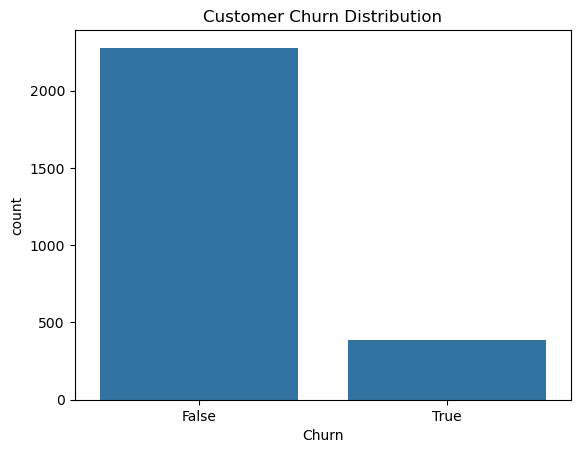

In [8]:
sns.countplot(x='Churn', data=train)
plt.title("Customer Churn Distribution")
plt.show()

Defining Features and Target:
We separate our data into X (the features like minutes used and charges) and y (the target variable: Churn).

In [9]:
X = train.drop('Churn', axis=1)
y = train['Churn']

Feature Scaling and Model Training:
Logistic Regression performs best when features are on the same scale. We use StandardScaler to normalize the data before training our model to ensure convergence.

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, y)

LogisticRegression(max_iter=1000)

Making Predictions:
Using the trained model, we predict the churn status for the unseen test data. We make sure to apply the same scaling to the test set as we did to the training set.

In [11]:
X_test = test.drop('Churn', axis=1)
y_test = test['Churn']

X_test_scaled = scaler.transform(X_test)

predictions = model.predict(X_test_scaled)

Model Performance/Accuracy:
We calculate the Accuracy Score to see what percentage of our predictions were correct.

In [12]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.8590704647676162


Confusion Matrix Visualization:
Finally, we use a heatmap to visualize the Confusion Matrix. This shows us exactly how many customers were correctly or incorrectly classified as "Churned."

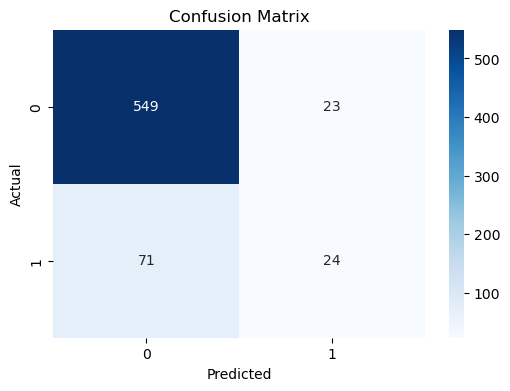

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()